## Single-Risk DeepHit — Separate Default & Prepay Models

Tests whether training **two separate single-risk models** improves discrimination vs the competing-risks DeepHit.
- Morgan's RF trains separate default/prepay models and gets strong prepay separation (KS=0.67)
- Our competing-risks DeepHit uses a shared backbone — maybe forcing both risks through one representation hurts prepay
- Same 9 features, same split, same architecture (128→64→32 MLP) — only difference is `num_risks=1`
- Default model: treats prepay as censored. Prepay model: treats default as censored.

In [1]:
# ===== 1. DATA PREP: Loan-level survival format (identical to DeepHit.ipynb) =====
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_csv('../data/prosperLoanData.csv')
fed_df = pd.read_csv('../data/FEDFUNDS.csv')
tb3ms_df = pd.read_csv('../data/TB3MS.csv')
unrate_df = pd.read_csv('../data/UNRATE.csv')

# Clean dates
df['ListingCreationDate'] = pd.to_datetime(df['ListingCreationDate'], format='mixed')
df['ClosedDate'] = pd.to_datetime(df['ClosedDate'], format='mixed')
df['LoanOriginationDate'] = pd.to_datetime(df['LoanOriginationDate'], format='mixed')

# Remove cancelled loans
df = df[~df['LoanStatus'].isin(['Cancelled'])]

# Identify prepaid loans
df['Prepayment'] = (
    df['LoanStatus'].isin(['Completed']) &
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30 < df['Term'] - 1)
)

# Event type: 0=censored, 1=default, 2=prepay
def assign_event(row):
    if row['LoanStatus'] in ['Defaulted', 'Chargedoff']:
        return 1
    elif row['Prepayment']:
        return 2
    else:
        return 0

df['event'] = df.apply(assign_event, axis=1)

# Duration: months from origination to event or last observation
as_of_date = pd.to_datetime('2014-03-10')
df['duration'] = np.where(
    df['event'] > 0,
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1),
    ((as_of_date - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1)
)
df['duration'] = df['duration'].clip(upper=36).astype(int)

# FED rate at origination
fed_df['observation_date'] = pd.to_datetime(fed_df['observation_date'])
fed_monthly = fed_df.set_index('observation_date').resample('MS').first().ffill()
fed_dict = fed_monthly['FEDFUNDS'].to_dict()
df['orig_month'] = df['LoanOriginationDate'].dt.to_period('M').dt.to_timestamp()
df['fed_at_orig'] = df['orig_month'].map(fed_dict)

# T-bill rate at origination
tb3ms_df['observation_date'] = pd.to_datetime(tb3ms_df['observation_date'])
tb3ms_monthly = tb3ms_df.set_index('observation_date').resample('MS').first().ffill()
tb3ms_dict = tb3ms_monthly['TB3MS'].to_dict()
df['tb3ms_at_orig'] = df['orig_month'].map(tb3ms_dict)

# Unemployment rate at origination
unrate_df['observation_date'] = pd.to_datetime(unrate_df['observation_date'])
unrate_monthly = unrate_df.set_index('observation_date').resample('MS').first().ffill()
unrate_dict = unrate_monthly['UNRATE'].to_dict()
df['unrate_at_orig'] = df['orig_month'].map(unrate_dict)

# ---- Feature engineering (loan/market features only — no borrower features) ----
df['apr_fed_spread'] = df['BorrowerRate'] - df['fed_at_orig'] / 100
df['apr_tbill_spread'] = df['BorrowerRate'] - df['tb3ms_at_orig'] / 100
df['loan_amount_log'] = np.log1p(df['LoanOriginalAmount'])
df['monthly_payment'] = df['MonthlyLoanPayment']

feature_cols = [
    'BorrowerRate', 'fed_at_orig', 'tb3ms_at_orig', 'unrate_at_orig',
    'apr_fed_spread', 'apr_tbill_spread',
    'loan_amount_log', 'Term', 'monthly_payment'
]

surv_df = df[feature_cols + ['duration', 'event', 'LoanOriginationDate']].dropna()
surv_df = surv_df[surv_df['BorrowerRate'] > 0]

print(f'Loans: {len(surv_df):,}')
print(f'Events: {surv_df["event"].value_counts().to_dict()}')
print(f'Duration range: {surv_df["duration"].min()} - {surv_df["duration"].max()}')
print(f'Features: {len(feature_cols)}')
print(f'Year range: {surv_df["LoanOriginationDate"].dt.year.min()} - {surv_df["LoanOriginationDate"].dt.year.max()}')

Loans: 113,924
Events: {0: 69435, 2: 27480, 1: 17009}
Duration range: 1 - 36
Features: 9
Year range: 2005 - 2014


In [2]:
# ===== 2. TRAIN/VAL/TEST SPLIT (temporal, matching Morgan's RF) =====
# Train: 2005-2010 | Validate: 2011 | Test: 2012-2014
from sklearn.preprocessing import StandardScaler

train = surv_df[surv_df['LoanOriginationDate'].dt.year <= 2010].copy()
val   = surv_df[surv_df['LoanOriginationDate'].dt.year == 2011].copy()
test  = surv_df[surv_df['LoanOriginationDate'].dt.year >= 2012].copy()

# Standardize features (fit on train only)
scaler = StandardScaler()
x_train = scaler.fit_transform(train[feature_cols]).astype('float32')
x_val   = scaler.transform(val[feature_cols]).astype('float32')
x_test  = scaler.transform(test[feature_cols]).astype('float32')

# Original event labels (0=censored, 1=default, 2=prepay)
y_train_dur = train['duration'].values
y_train_evt = train['event'].values
y_val_dur   = val['duration'].values
y_val_evt   = val['event'].values
y_test_dur  = test['duration'].values
y_test_evt  = test['event'].values

print(f'Train (\u22642010): {len(train):,} | Val (2011): {len(val):,} | Test (\u22652012): {len(test):,}')
print(f'Train events: { {k: v for k, v in zip(*np.unique(y_train_evt, return_counts=True))} }')
print(f'Val events:   { {k: v for k, v in zip(*np.unique(y_val_evt, return_counts=True))} }')
print(f'Test events:  { {k: v for k, v in zip(*np.unique(y_test_evt, return_counts=True))} }')

Train (≤2010): 36,626 | Val (2011): 11,228 | Test (≥2012): 66,070
Train events: {np.int64(0): np.int64(9576), np.int64(1): np.int64(11904), np.int64(2): np.int64(15146)}
Val events:   {np.int64(0): np.int64(4121), np.int64(1): np.int64(2145), np.int64(2): np.int64(4962)}
Test events:  {np.int64(0): np.int64(55738), np.int64(1): np.int64(2960), np.int64(2): np.int64(7372)}


Default model — event distribution:
  Train: 11,904 defaults, 24,722 censored (prepay+ongoing)
  Val:   2,145 defaults, 9,083 censored

Default model params: 13,252
Output shape: [batch, 1, 36]


c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\torchtuples\callbacks.py:607: UserWarning: This overload of add is deprecated:
	add(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1862.)
  p.data = p.data.add(-weight_decay * eta, p.data)


0:	[1s / 1s],		train_loss: 1.3906,	val_loss: 1.2789
1:	[1s / 2s],		train_loss: 1.3456,	val_loss: 0.9670
2:	[1s / 3s],		train_loss: 1.3178,	val_loss: 0.9055
3:	[1s / 4s],		train_loss: 1.2996,	val_loss: 0.8970
4:	[1s / 5s],		train_loss: 1.2789,	val_loss: 0.8569
5:	[1s / 6s],		train_loss: 1.2587,	val_loss: 0.8259
6:	[0s / 7s],		train_loss: 1.2346,	val_loss: 0.8075
7:	[1s / 8s],		train_loss: 1.2067,	val_loss: 0.7942
8:	[1s / 9s],		train_loss: 1.1740,	val_loss: 0.7742
9:	[0s / 10s],		train_loss: 1.1333,	val_loss: 0.7607
10:	[1s / 11s],		train_loss: 1.0916,	val_loss: 0.7277
11:	[1s / 13s],		train_loss: 1.0538,	val_loss: 0.6989
12:	[1s / 14s],		train_loss: 1.0163,	val_loss: 0.6711
13:	[1s / 15s],		train_loss: 0.9881,	val_loss: 0.6655
14:	[1s / 16s],		train_loss: 0.9629,	val_loss: 0.6676
15:	[1s / 17s],		train_loss: 0.9464,	val_loss: 0.6587
16:	[1s / 18s],		train_loss: 0.9316,	val_loss: 0.6425
17:	[0s / 19s],		train_loss: 0.9210,	val_loss: 0.6290
18:	[0s / 20s],		train_loss: 0.9117,	val_loss: 

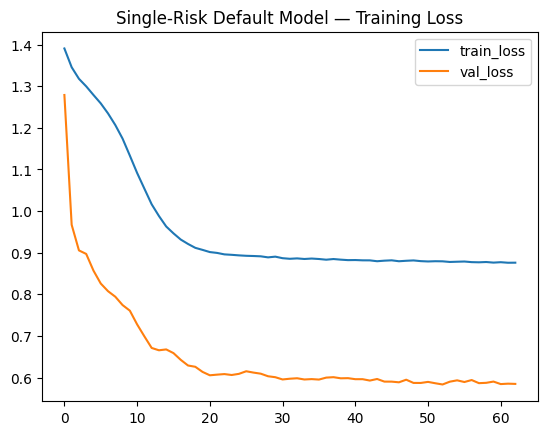

In [3]:
# ===== 3. SINGLE-RISK DEFAULT MODEL =====
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHit
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

num_durations = 36
in_features = x_train.shape[1]

# --- Remap events: default=1, everything else=censored (0) ---
y_train_evt_def = (y_train_evt == 1).astype('float64')
y_val_evt_def   = (y_val_evt == 1).astype('float64')
y_test_evt_def  = (y_test_evt == 1).astype('float64')

labtrans_def = LabTransDiscreteTime(num_durations)
y_train_def = labtrans_def.fit_transform(y_train_dur.astype('float64'), y_train_evt_def)
y_val_def   = labtrans_def.transform(y_val_dur.astype('float64'), y_val_evt_def)
y_train_def = (y_train_def[0].astype('int64'), y_train_def[1].astype('int64'))
y_val_def   = (y_val_def[0].astype('int64'), y_val_def[1].astype('int64'))

print(f'Default model — event distribution:')
print(f'  Train: {int(y_train_evt_def.sum()):,} defaults, {int((y_train_evt_def == 0).sum()):,} censored (prepay+ongoing)')
print(f'  Val:   {int(y_val_evt_def.sum()):,} defaults, {int((y_val_evt_def == 0).sum()):,} censored')

# --- Network: output [batch, 1, num_durations] for DeepHit loss compatibility ---
class SingleRiskNet(nn.Module):
    def __init__(self, in_features, num_durations):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            nn.Linear(32, num_durations),
        )
    
    def forward(self, x):
        return self.mlp(x).unsqueeze(1)  # [batch, 1, num_durations]

net_def = SingleRiskNet(in_features, labtrans_def.out_features)

model_def = DeepHit(
    net_def,
    tt.optim.Adam(lr=0.0005),
    duration_index=labtrans_def.cuts,
    alpha=0.5,
    sigma=0.1,
)

print(f'\nDefault model params: {sum(p.numel() for p in net_def.parameters()):,}')
print(f'Output shape: [batch, 1, {labtrans_def.out_features}]')

# --- Train ---
callbacks_def = [
    tt.callbacks.EarlyStopping(patience=10),
    tt.callbacks.DecoupledWeightDecay(weight_decay=1e-4),
]

log_def = model_def.fit(
    x_train, y_train_def,
    batch_size=512,
    epochs=100,
    callbacks=callbacks_def,
    val_data=(x_val, y_val_def),
    verbose=True
)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
log_def.plot(ax=ax)
ax.set_title('Single-Risk Default Model — Training Loss')
plt.show()

Prepay model — event distribution:
  Train: 15,146 prepays, 21,480 censored (default+ongoing)
  Val:   4,962 prepays, 6,266 censored

Prepay model params: 13,252
0:	[1s / 1s],		train_loss: 1.5613,	val_loss: 1.8424
1:	[1s / 2s],		train_loss: 1.5174,	val_loss: 1.7113
2:	[1s / 3s],		train_loss: 1.4994,	val_loss: 1.5530
3:	[1s / 4s],		train_loss: 1.4834,	val_loss: 1.6617
4:	[1s / 5s],		train_loss: 1.4718,	val_loss: 1.4638
5:	[1s / 6s],		train_loss: 1.4548,	val_loss: 1.3998
6:	[1s / 7s],		train_loss: 1.4378,	val_loss: 1.3673
7:	[1s / 8s],		train_loss: 1.4157,	val_loss: 1.3606
8:	[1s / 9s],		train_loss: 1.3906,	val_loss: 1.3324
9:	[1s / 10s],		train_loss: 1.3615,	val_loss: 1.3254
10:	[1s / 11s],		train_loss: 1.3266,	val_loss: 1.3157
11:	[1s / 12s],		train_loss: 1.2925,	val_loss: 1.2835
12:	[1s / 13s],		train_loss: 1.2589,	val_loss: 1.2598
13:	[1s / 14s],		train_loss: 1.2387,	val_loss: 1.2443
14:	[1s / 15s],		train_loss: 1.2151,	val_loss: 1.2285
15:	[1s / 16s],		train_loss: 1.2004,	val_loss: 

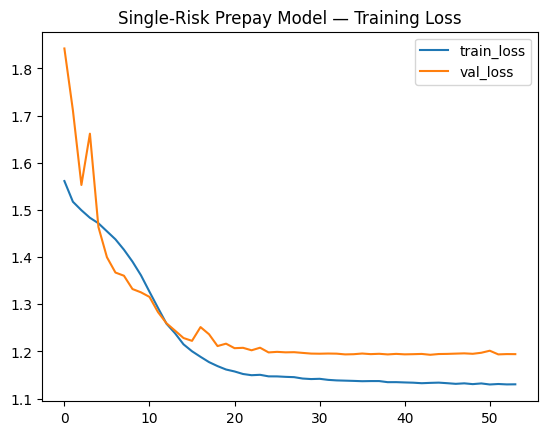

In [4]:
# ===== 4. SINGLE-RISK PREPAY MODEL =====

# --- Remap events: prepay=1, everything else=censored (0) ---
y_train_evt_pre = (y_train_evt == 2).astype('float64')
y_val_evt_pre   = (y_val_evt == 2).astype('float64')
y_test_evt_pre  = (y_test_evt == 2).astype('float64')

labtrans_pre = LabTransDiscreteTime(num_durations)
y_train_pre = labtrans_pre.fit_transform(y_train_dur.astype('float64'), y_train_evt_pre)
y_val_pre   = labtrans_pre.transform(y_val_dur.astype('float64'), y_val_evt_pre)
y_train_pre = (y_train_pre[0].astype('int64'), y_train_pre[1].astype('int64'))
y_val_pre   = (y_val_pre[0].astype('int64'), y_val_pre[1].astype('int64'))

print(f'Prepay model — event distribution:')
print(f'  Train: {int(y_train_evt_pre.sum()):,} prepays, {int((y_train_evt_pre == 0).sum()):,} censored (default+ongoing)')
print(f'  Val:   {int(y_val_evt_pre.sum()):,} prepays, {int((y_val_evt_pre == 0).sum()):,} censored')

# --- Network ---
net_pre = SingleRiskNet(in_features, labtrans_pre.out_features)

model_pre = DeepHit(
    net_pre,
    tt.optim.Adam(lr=0.0005),
    duration_index=labtrans_pre.cuts,
    alpha=0.5,
    sigma=0.1,
)

print(f'\nPrepay model params: {sum(p.numel() for p in net_pre.parameters()):,}')

# --- Train ---
callbacks_pre = [
    tt.callbacks.EarlyStopping(patience=10),
    tt.callbacks.DecoupledWeightDecay(weight_decay=1e-4),
]

log_pre = model_pre.fit(
    x_train, y_train_pre,
    batch_size=512,
    epochs=100,
    callbacks=callbacks_pre,
    val_data=(x_val, y_val_pre),
    verbose=True
)

fig, ax = plt.subplots()
log_pre.plot(ax=ax)
ax.set_title('Single-Risk Prepay Model — Training Loss')
plt.show()

In [5]:
# ===== 5. EVALUATE BOTH MODELS (test set: 2012-2014) =====
from pycox.evaluation import EvalSurv
from sklearn.metrics import average_precision_score
from scipy.stats import ks_2samp

# Fix scipy compatibility
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

# Get survival functions (single-risk → predict_surv_df)
surv_def = model_def.predict_surv_df(x_test)
surv_pre = model_pre.predict_surv_df(x_test)

# Risk score = 1 - S(t) = cumulative incidence
risk_def = 1 - surv_def.values  # [time_steps, loans]
risk_pre = 1 - surv_pre.values

print(f'Survival DF shape: {surv_def.shape} (time_steps x loans)')

# ========== DEFAULT MODEL ==========
print('\n' + '='*60)
print('DEFAULT MODEL (single-risk)')
print('='*60)

# C-index (use censored + default loans only, matching competing-risks eval)
mask_def = (y_test_evt == 0) | (y_test_evt == 1)
ev_def = EvalSurv(
    surv_def.iloc[:, mask_def],
    y_test_dur[mask_def],
    (y_test_evt[mask_def] == 1).astype(float),
    censor_surv='km'
)
c_def = ev_def.concordance_td()
time_grid = np.linspace(1, 36, 36)
ibs_def = ev_def.integrated_brier_score(time_grid)
print(f'\n  C-index: {c_def:.3f}')
print(f'  IBS:     {ibs_def:.4f}')

# PR-AUC
pred_def_t36 = risk_def[-1, :]
actual_def = (y_test_evt == 1).astype(int)
pr_auc_def = average_precision_score(actual_def, pred_def_t36)
print(f'  PR-AUC (t=36): {pr_auc_def:.3f}  (base rate: {actual_def.mean():.4f})')

pred_def_t12 = risk_def[11, :]
actual_def_t12 = ((y_test_evt == 1) & (y_test_dur <= 12)).astype(int)
pr_auc_def_t12 = average_precision_score(actual_def_t12, pred_def_t12)
print(f'  PR-AUC (t=12): {pr_auc_def_t12:.3f}  (base rate: {actual_def_t12.mean():.4f})')

# KS
def_event_scores = pred_def_t36[y_test_evt == 1]
def_non_event_scores = pred_def_t36[y_test_evt != 1]
ks_def, ks_def_p = ks_2samp(def_event_scores, def_non_event_scores)
print(f'  KS: {ks_def:.3f}  (p={ks_def_p:.2e})')

# Lift
print(f'\n  Lift by Decile (at t=12):')
order = np.argsort(-pred_def_t12)
decile_size = len(order) // 10
baseline_rate = actual_def_t12.mean()
print(f'  Baseline rate: {baseline_rate:.4f}')
for d in range(10):
    idx = order[d * decile_size:(d + 1) * decile_size]
    rate = actual_def_t12[idx].mean()
    lift = rate / baseline_rate if baseline_rate > 0 else 0
    bar = '#' * int(lift * 5)
    print(f'    Decile {d+1:2d}: rate={rate:.4f}  lift={lift:.2f}x  {bar}')

# ========== PREPAY MODEL ==========
print('\n' + '='*60)
print('PREPAY MODEL (single-risk)')
print('='*60)

# C-index (use censored + prepay loans only)
mask_pre = (y_test_evt == 0) | (y_test_evt == 2)
ev_pre = EvalSurv(
    surv_pre.iloc[:, mask_pre],
    y_test_dur[mask_pre],
    (y_test_evt[mask_pre] == 2).astype(float),
    censor_surv='km'
)
c_pre = ev_pre.concordance_td()
ibs_pre = ev_pre.integrated_brier_score(time_grid)
print(f'\n  C-index: {c_pre:.3f}')
print(f'  IBS:     {ibs_pre:.4f}')

# PR-AUC
pred_pre_t36 = risk_pre[-1, :]
actual_pre = (y_test_evt == 2).astype(int)
pr_auc_pre = average_precision_score(actual_pre, pred_pre_t36)
print(f'  PR-AUC (t=36): {pr_auc_pre:.3f}  (base rate: {actual_pre.mean():.4f})')

pred_pre_t12 = risk_pre[11, :]
actual_pre_t12 = ((y_test_evt == 2) & (y_test_dur <= 12)).astype(int)
pr_auc_pre_t12 = average_precision_score(actual_pre_t12, pred_pre_t12)
print(f'  PR-AUC (t=12): {pr_auc_pre_t12:.3f}  (base rate: {actual_pre_t12.mean():.4f})')

# KS
pre_event_scores = pred_pre_t36[y_test_evt == 2]
pre_non_event_scores = pred_pre_t36[y_test_evt != 2]
ks_pre, ks_pre_p = ks_2samp(pre_event_scores, pre_non_event_scores)
print(f'  KS: {ks_pre:.3f}  (p={ks_pre_p:.2e})')

# Lift
print(f'\n  Lift by Decile (at t=12):')
order = np.argsort(-pred_pre_t12)
decile_size = len(order) // 10
baseline_rate = actual_pre_t12.mean()
print(f'  Baseline rate: {baseline_rate:.4f}')
for d in range(10):
    idx = order[d * decile_size:(d + 1) * decile_size]
    rate = actual_pre_t12[idx].mean()
    lift = rate / baseline_rate if baseline_rate > 0 else 0
    bar = '#' * int(lift * 5)
    print(f'    Decile {d+1:2d}: rate={rate:.4f}  lift={lift:.2f}x  {bar}')

Survival DF shape: (36, 66070) (time_steps x loans)

DEFAULT MODEL (single-risk)

  C-index: 0.607
  IBS:     0.1989
  PR-AUC (t=36): 0.061  (base rate: 0.0448)
  PR-AUC (t=12): 0.036  (base rate: 0.0264)
  KS: 0.204  (p=4.92e-104)

  Lift by Decile (at t=12):
  Baseline rate: 0.0264
    Decile  1: rate=0.0278  lift=1.06x  #####
    Decile  2: rate=0.0763  lift=2.89x  ##############
    Decile  3: rate=0.0294  lift=1.11x  #####
    Decile  4: rate=0.0174  lift=0.66x  ###
    Decile  5: rate=0.0085  lift=0.32x  #
    Decile  6: rate=0.0068  lift=0.26x  #
    Decile  7: rate=0.0419  lift=1.59x  #######
    Decile  8: rate=0.0265  lift=1.00x  #####
    Decile  9: rate=0.0145  lift=0.55x  ##
    Decile 10: rate=0.0148  lift=0.56x  ##

PREPAY MODEL (single-risk)

  C-index: 0.541
  IBS:     0.1779
  PR-AUC (t=36): 0.169  (base rate: 0.1116)
  PR-AUC (t=12): 0.142  (base rate: 0.0815)
  KS: 0.244  (p=0.00e+00)

  Lift by Decile (at t=12):
  Baseline rate: 0.0815
    Decile  1: rate=0.1321  l

In [6]:
# ===== 6. HEAD-TO-HEAD COMPARISON =====
print('='*70)
print('SINGLE-RISK vs COMPETING-RISKS DeepHit vs Morgan RF')
print('='*70)
print()
print(f'{"Metric":<25} {"Single-Risk":<15} {"Competing":<15} {"Morgan RF":<15}')
print('-' * 70)
print(f'{"Default C-index":<25} {c_def:<15.3f} {"0.579":<15} {"—":<15}')
print(f'{"Prepay C-index":<25} {c_pre:<15.3f} {"0.518":<15} {"—":<15}')
print(f'{"Default IBS":<25} {ibs_def:<15.4f} {"0.1252":<15} {"—":<15}')
print(f'{"Prepay IBS":<25} {ibs_pre:<15.4f} {"0.4024":<15} {"—":<15}')
print(f'{"Default KS":<25} {ks_def:<15.3f} {"0.287":<15} {"0.051":<15}')
print(f'{"Prepay KS":<25} {ks_pre:<15.3f} {"0.141":<15} {"0.67":<15}')
print(f'{"Default PR-AUC (t=36)":<25} {pr_auc_def:<15.3f} {"0.075":<15} {"0.010":<15}')
print(f'{"Prepay PR-AUC (t=36)":<25} {pr_auc_pre:<15.3f} {"0.135":<15} {"0.007":<15}')
print()
print('Competing-risks values from DeepHit.ipynb (ground truth).')
print('Morgan RF values from her latest run on same split.')

SINGLE-RISK vs COMPETING-RISKS DeepHit vs Morgan RF

Metric                    Single-Risk     Competing       Morgan RF      
----------------------------------------------------------------------
Default C-index           0.607           0.579           —              
Prepay C-index            0.541           0.518           —              
Default IBS               0.1989          0.1252          —              
Prepay IBS                0.1779          0.4024          —              
Default KS                0.204           0.287           0.051          
Prepay KS                 0.244           0.141           0.67           
Default PR-AUC (t=36)     0.061           0.075           0.010          
Prepay PR-AUC (t=36)      0.169           0.135           0.007          

Competing-risks values from DeepHit.ipynb (ground truth).
Morgan RF values from her latest run on same split.
